# Student Productivity and Cognitive Efficiency Analysis



# Problem statement 


1) In today’s digital era, students are increasingly exposed to screen-based activities such as mobile usage and social media.This leads to several issues like reduced attention span, poor sleep quality, and increased stress levels.

2) These factors directly impact cognitive performance and productivity, but the exact relationship between them is not clearly understood.

3) Therefore, the problem is to analyze and quantify how lifestyle factors like screen time, sleep, and stress influence student productivity and cognitive efficiency using data analysis.


## import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

##  Step 1: Load Dataset

In [2]:
df_original = pd.read_csv(r"C:\Users\yuvar\OneDrive\final_powerbi_project\screen_time_dataset_messy.csv")

print("Original Shape:", df_original.shape)
df_original.head()

Original Shape: (3025, 11)


,Student_ID,Age,Gender,Study_Hours,Screen_Time_Hours,Social_Media_Hours,Sleep_Hours,Productivity_Score,Cognitive_Test_Score,Stress_Level,Device_Type
0,1,Twenty,Female,5.45,5.62,3.34,8.28,95.0,85.0,Medium,Laptop
1,2,20,Female,6.74,Ten,1.99,6.80,100.0,96.0,Low,Mobile
2,3,21,Male,3.57,20,5.45,6.12,68.0,88.0,High,Mobile
3,4,23,Female,2.44,5.39,3.56,5.96,150.0,92.0,Medium,Mobile
4,5,20,Male,4.71,5.02,2.82,7.97,93.0,97.0,Medium,Laptop


In [3]:
df = df_original.copy()

print("Working Shape:", df.shape)

Working Shape: (3025, 11)


##  Step 1: Check Data Issues

In this step, we check:
- Data types
- Missing values
- Duplicate records

In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3025 entries, 0 to 3024
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Student_ID            3025 non-null   int64  
 1   Age                   3025 non-null   object 
 2   Gender                3025 non-null   object 
 3   Study_Hours           3025 non-null   float64
 4   Screen_Time_Hours     2940 non-null   object 
 5   Social_Media_Hours    3025 non-null   float64
 6   Sleep_Hours           3025 non-null   float64
 7   Productivity_Score    2984 non-null   float64
 8   Cognitive_Test_Score  3025 non-null   float64
 9   Stress_Level          3025 non-null   object 
 10  Device_Type           3025 non-null   object 
dtypes: float64(5), int64(1), object(5)
memory usage: 260.1+ KB


In [5]:
df.isnull().sum()


Student_ID               0
Age                      0
Gender                   0
Study_Hours              0
Screen_Time_Hours       85
Social_Media_Hours       0
Sleep_Hours              0
Productivity_Score      41
Cognitive_Test_Score     0
Stress_Level             0
Device_Type              0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(25)

###  Observation
The dataset contains:
- Missing values
- Incorrect data types
- Duplicate rows

Now we will clean them step by step.

##  Step 2: Fix Data Types
Convert Age, Screen Time, and Productivity into numeric format.

In [7]:
df["Age"] = pd.to_numeric(df["Age"], errors="coerce")
df["Screen_Time_Hours"] = pd.to_numeric(df["Screen_Time_Hours"], errors="coerce")
df["Productivity_Score"] = pd.to_numeric(df["Productivity_Score"], errors="coerce")

##  Step 3: Handle Missing Values

We will:
- Fill Screen Time using median
- Fill Productivity using mean
- Fill Age using median

In [8]:
df["Screen_Time_Hours"].fillna(df["Screen_Time_Hours"].median(), inplace=True)
df["Productivity_Score"].fillna(df["Productivity_Score"].mean(), inplace=True)
df["Age"].fillna(df["Age"].median(), inplace=True)

df.isnull().sum()

C:\Users\yuvar\AppData\Local\Temp\ipykernel_34460\3443460595.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Screen_Time_Hours"].fillna(df["Screen_Time_Hours"].median(), inplace=True)
C:\Users\yuvar\AppData\Local\Temp\ipykernel_34460\3443460595.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values alwa

Student_ID              0
Age                     0
Gender                  0
Study_Hours             0
Screen_Time_Hours       0
Social_Media_Hours      0
Sleep_Hours             0
Productivity_Score      0
Cognitive_Test_Score    0
Stress_Level            0
Device_Type             0
dtype: int64

##  Step 4: Remove Duplicate Records

In [9]:
df = df.drop_duplicates()
print(df)



      Student_ID   Age  Gender  Study_Hours  Screen_Time_Hours  \
0              1  21.0  Female         5.45               5.62   
1              2  20.0  Female         6.74               5.93   
2              3  21.0    Male         3.57              20.00   
3              4  23.0  Female         2.44               5.39   
4              5  20.0    Male         4.71               5.02   
...          ...   ...     ...          ...                ...   
2995        2996  21.0    Male         4.60               4.81   
2996        2997  21.0    Male         2.49               7.31   
2997        2998  19.0  Female         3.34               6.51   
2998        2999  21.0    Male         5.79               3.35   
2999        3000  20.0    Male         4.77               5.13   

      Social_Media_Hours  Sleep_Hours  Productivity_Score  \
0                   3.34         8.28                95.0   
1                   1.99         6.80               100.0   
2                   5.45

In [10]:
df.duplicated().sum()

np.int64(0)

##  Step 5: Remove Outliers

We remove unrealistic values:
- Screen Time greater than 14 hours
- Productivity greater than 100

In [11]:
df = df[df["Screen_Time_Hours"] <= 14]
df = df[df["Productivity_Score"] <= 100]



In [12]:
df.shape

(2998, 11)

##  Step 6: Feature Engineering

Create a new column called Screen_Time_Category:
- Low (<3 hours)
- Medium (3–6 hours)
- High (>6 hours)

In [13]:
def category(x):
    if x < 3:
        return "Low"
    elif x <= 6:
        return "Medium"
    else:
        return "High"

df["Screen_Time_Category"] = df["Screen_Time_Hours"].apply(category)

df.head()

,Student_ID,Age,Gender,Study_Hours,Screen_Time_Hours,Social_Media_Hours,Sleep_Hours,Productivity_Score,Cognitive_Test_Score,Stress_Level,Device_Type,Screen_Time_Category
0,1,21.0,Female,5.45,5.62,3.34,8.28,95.0,85.0,Medium,Laptop,Medium
1,2,20.0,Female,6.74,5.93,1.99,6.80,100.0,96.0,Low,Mobile,Medium
4,5,20.0,Male,4.71,5.02,2.82,7.97,93.0,97.0,Medium,Laptop,Medium
5,6,20.0,Male,2.36,9.18,5.74,6.48,73.0,79.0,High,Mobile,High
6,7,23.0,Male,4.37,3.52,1.56,6.83,99.0,100.0,Low,Mobile,Medium


#  Exploratory Data Analysis (EDA)

## 1️ Distribution of Screen Time

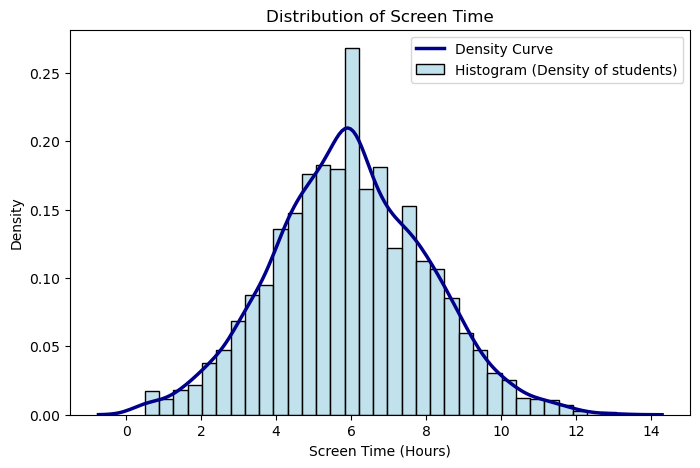

In [14]:
plt.figure(figsize=(8,5))

# Histogram scaled to density
sns.histplot(
    df["Screen_Time_Hours"],
    stat="density",
    color="lightblue",
    edgecolor="black",
    label="Histogram (Density of students)"
)

# KDE line
sns.kdeplot(
    df["Screen_Time_Hours"],
    color="darkblue",
    linewidth=2.5,
    label="Density Curve"
)

plt.title("Distribution of Screen Time")
plt.xlabel("Screen Time (Hours)")
plt.ylabel("Density")

plt.legend()
plt.show()

###  Insight

- Most students use screens between 4–8 hours per day, with the highest concentration around 5–6 hours.

- Only a small number of students show very low or very high screen usage.
####  What is Density?

Density shows the proportion of student data instead of count

####  Why is it Used?

Helps to understand data distribution clearly
- Makes comparison easier between datasets
- Matches histogram with KDE curve
- Shows proportion instead of exact count

##  Correlation Graph

This heatmap shows the strength and direction of relationships 
between numerical variables in the dataset.

Correlation values range from:
- +1 → Strong Positive Relationship
-  0 → No Relationship
- -1 → Strong Negative Relationship

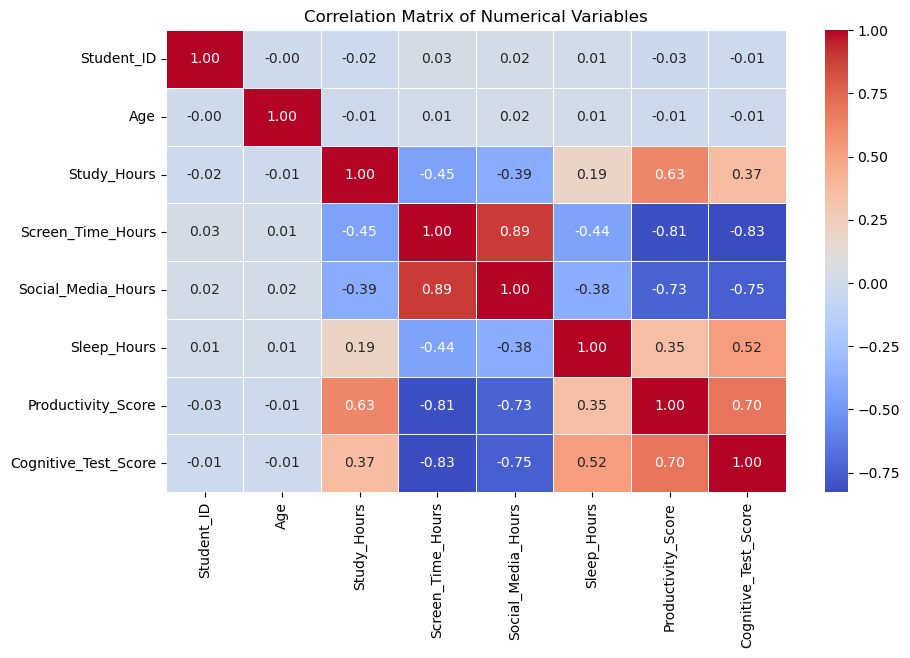

In [15]:
plt.figure(figsize=(10,6))

# Calculate correlation matrix
corr_matrix = df.corr(numeric_only=True)

# Plot heatmap
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)
corr_matrix = df.drop(columns=["Student_ID"]).corr(numeric_only=True)
plt.title("Correlation Matrix of Numerical Variables")
plt.show()



##  Dependent Variable (The Final Output)
This is the **target** of our analysis—the result we want to explain.

* **`Productivity_Score`**: The primary dependent variable representing the final performance of the student.



##  Intermediate Variable (The Mediator)
This variable acts as a bridge between lifestyle habits and the final output.

* **`Cognitive_Test_Score`**: 
    * **Role:** It explains the *mental state* required for productivity.
    * **Insight:** It is influenced by habits (like sleep and screen time) and, in turn, heavily dictates the final productivity score ($0.70$ correlation).



## Independent Variables 
These are the inputs or "causes" that can be manipulated to change the outcome.

| Variable | Influence Type | Correlation to Productivity |
| :--- | :--- | :--- |
| **`Study_Hours`** | **Positive** | `+0.63` (Strong direct impact) |
| **`Sleep_Hours`** | **Positive** | `+0.35` (Supports cognitive function) |
| **`Screen_Time_Hours`** | **Negative** | `-0.81` (Very Strong Negative ) |
| **`Social_Media_Hours`** | **Negative** | `-0.73` (Strong Negative) |



## The Analytical Flow
> **`Social_Media_Hours`** ,**`Scren_Time_Hours`** (Independent) $\rightarrow$ **Cognitive Health** (Intermediate) $\rightarrow$ **Productivity** (Dependent)

###  Insight

- The correlation matrix shows a strong negative relationship between screen time and both productivity and cognitive performance.

- It also indicates a positive relationship between study hours and productivity, suggesting that increased study time improves academic performance.

## 2 Screen Time vs Productivity

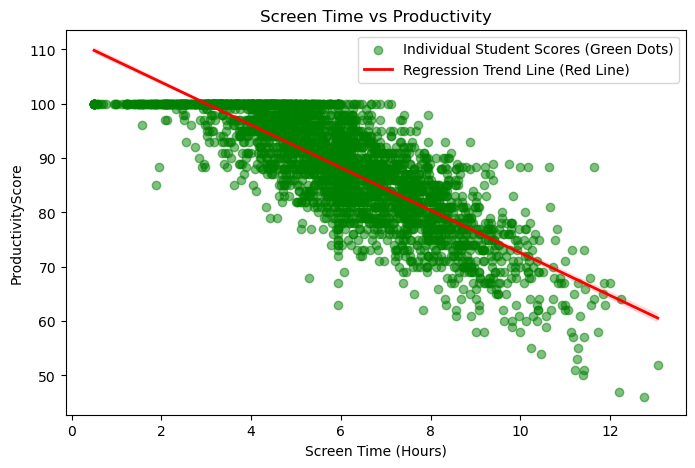

In [16]:
plt.figure(figsize=(8,5))

# Scatter (Green Dots)
plt.scatter(
    df["Screen_Time_Hours"],
    df["Productivity_Score"],
    alpha=0.5,
    color="green",
    label="Individual Student Scores (Green Dots)"
)

# Regression Line (Red)
sns.regplot(
    x="Screen_Time_Hours",
    y="Productivity_Score",
    data=df,
    scatter=False,
    line_kws={"color":"red", "linewidth":2}
)

# Add legend entry for red line
plt.plot([], [], color='red', linewidth=2,
         label="Regression Trend Line (Red Line)")

plt.title("Screen Time vs Productivity")
plt.xlabel("Screen Time (Hours)")
plt.ylabel("ProductivityScore")

plt.legend()
plt.show()

In [17]:
corr_value = df["Screen_Time_Hours"].corr(df["Productivity_Score"])
print("Correlation Value:", round(corr_value, 2))

Correlation Value: -0.81



There is a strong negative relationship between screen time and productivity.
As screen time increases, productivity decreases.

###  Insight

The correlation value of -0.81 indicates a strong negative relationship between screen time and productivity.

This confirms that as screen time increases, productivity significantly decreases.

Correlation < 0 → Negative relationship

Closer to -1 → Strong negative relationship

-0.83 is very close to -1
So it is a strong negative correlation.

### Variable Hierarchy
| Correlation Range | Strength | Variable | Action Priority |
| :--- | :--- | :--- | :--- |
| -0.80 to -1.0 | **Very Strong** | `Screen_Time_Hours` | **Critical:** Must be reduced first. |
| -0.60 to -0.79 | **Strong** | `Social_Media_Hours` | **High:** The main area for improvement. |

## 4️ Productivity by  Social media hours

C:\Users\yuvar\AppData\Local\Temp\ipykernel_34460\2442926778.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


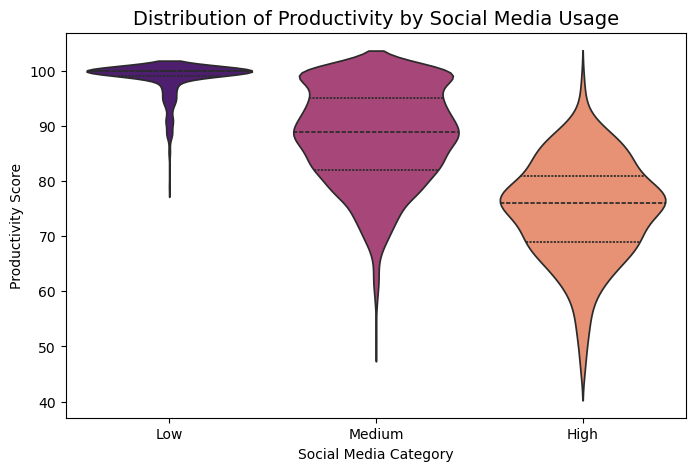

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create categories (IMPORTANT)
df["Social_Media_Category"] = pd.cut(
    df["Social_Media_Hours"],
    bins=[0, 2, 5, 10],
    labels=["Low", "Medium", "High"]
)

plt.figure(figsize=(8,5))

sns.violinplot(
    x="Social_Media_Category",
    y="Productivity_Score",
    data=df,
    palette="magma",
    inner="quartile"
)

plt.title("Distribution of Productivity by Social Media Usage", fontsize=14)
plt.xlabel("Social Media Category")
plt.ylabel("Productivity Score")

plt.show()



### Insights
- Productivity decreases as social media usage increases
- Low usage results in more consistent performance
- High usage leads to greater variability in productivity
- Increased spread indicates unstable performance among heavy users


## 4  Average  cognitive score by screen time catogary

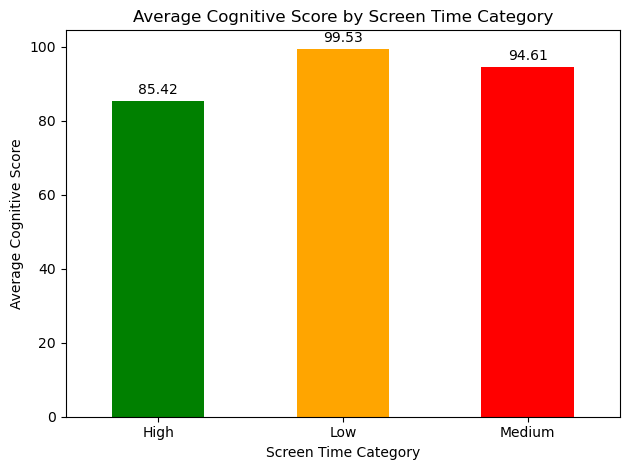

In [19]:
import matplotlib.pyplot as plt

# Assign the plot to an axes object 'ax'
ax = df.groupby("Screen_Time_Category")["Cognitive_Test_Score"].mean().plot(
    kind="bar",
    color=["green", "orange", "red"]
)

# Add data labels using ax.containers
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)

# Formatting
plt.title("Average Cognitive Score by Screen Time Category")
plt.ylabel("Average Cognitive Score")
plt.xlabel("Screen Time Category")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### insights 
Students in the Low screen time category show higher cognitive performance compared to High usage groups.

## 5️ Study Hours vs Productivity

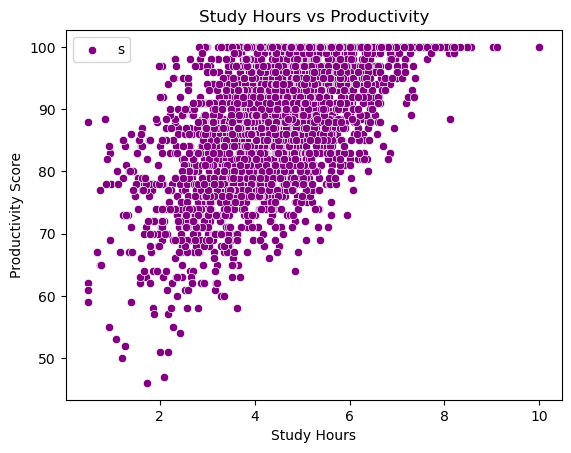

In [20]:
sns.scatterplot(
    x="Study_Hours",
    y="Productivity_Score",
    data=df,
    color="purple"
)

plt.title("Study Hours vs Productivity")
plt.xlabel("Study Hours")
plt.ylabel("Productivity Score")
plt.legend("students data points")
plt.show()

### insights:
There is a positive relationship between study hours and productivity, suggesting that increased study time improves academic performance.

## 5️ Stress Level Distribution

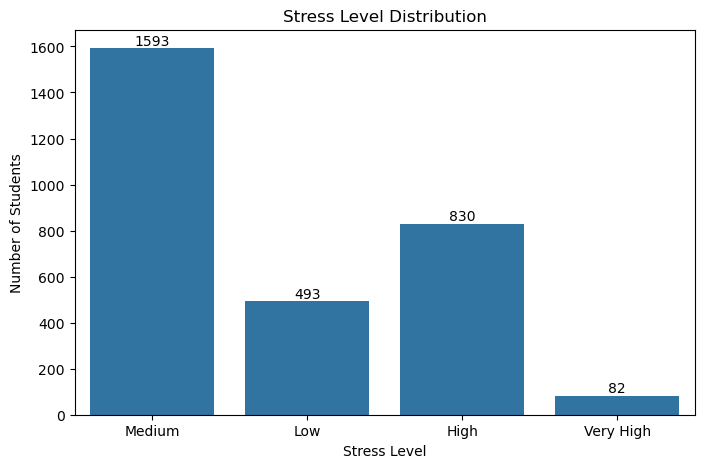

In [21]:
plt.figure(figsize=(8,5))

ax = sns.countplot(x="Stress_Level", data=df)

plt.title("Stress Level Distribution")
plt.xlabel("Stress Level")
plt.ylabel("Number of Students")

# Add count labels
for container in ax.containers:
    ax.bar_label(container)
plt.show() 

###  Insight
Higher screen time groups tend to report higher stress.

# Machine Learning Model: Linear Regression for Productivity Prediction

To further analyze the relationship between screen time and student well-being, a simple Machine Learning model was implemented.

A **Linear Regression model** predict the Productivity Score of student based on the following features:

- Screen Time
- Social Media Usage
- Sleep Hours
- Study Hours

The dataset was split into training and testing sets to evaluate the model's performance. The model was evaluated using **Mean Squared Error (MSE)** and **R² Score**.

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Features
X = df[["Screen_Time_Hours","Social_Media_Hours","Sleep_Hours","Study_Hours"]]

# Target
y = df["Productivity_Score"]

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MSE: 27.68567699464919
R2 Score: 0.7356288538265657


| Metric | Range | Interpretation |
|--------|------|----------------|
| R² Score | 0 – 0.3 | Poor |
| R² Score | 0.3 – 0.5 | Weak |
| R² Score | 0.5 – 0.7 | Moderate |
| R² Score | 0.7 – 0.9 | Good |
| R² Score | 0.9 – 1 | Excellent |
| MSE | 0 | Perfect prediction |
| MSE | Low value | Good model |
| MSE | High value | Poor model |

## Model Evaluation

A Linear Regression model was trained to predict **student productivity score** using lifestyle factors such as screen time, social media usage, sleep hours, and study hours.

The dataset was split into training and testing sets to evaluate the performance of the model.

Two evaluation metrics were used:

- **Mean Squared Error (MSE):** Measures the average squared difference between predicted and actual values.
- **R² Score:** Indicates how well the model explains the variation in the target variable.

### Results
- **MSE:** 27.69  
- **R² Score:** 0.73

The R² score of 0.73 indicates that approximately **73% of the variation in student productivity can be explained by the selected features**.

## Model Insights

The machine learning model provides several insights into the relationship between digital habits and student productivity:

- Higher **screen time** is associated with lower productivity levels.
- Increased **social media usage** may negatively affect academic focus.
- Students with **adequate sleep hours** tend to have better productivity scores.
- **Study hours** positively influence productivity and learning outcomes.

Overall, the model confirms the patterns observed during the exploratory data analysis phase and highlights the importance of balanced digital habits for maintaining student productivity.

##  Final Step: Export Clean Dataset for Power BI

In [23]:
df.to_csv("screen_time_final_cleaned.csv", index=False)

print("Clean dataset exported successfully!")

Clean dataset exported successfully!


## Key Insights (EDA)

- Screen time has a strong negative impact on both cognitive score and productivity  
- Social media usage negatively affects productivity and increases variability  
- Sleep has a positive effect on cognitive performance  
- Study hours positively influence productivity  
- Cognitive score strongly contributes to productivity  
- High screen time and social media usage are the main factors reducing performance

## Conclusion (EDA)

- Student performance is highly influenced by lifestyle habits  
- Negative factors like screen time and social media reduce productivity  
- Positive factors like sleep and study improve performance  
- Cognitive ability plays an important role in determining productivity  
- Managing these factors can lead to better student outcomes